# FLAMINGO integrated lightcone maps — yang26 / lightcone0

This notebook loads and visualizes **integrated HEALPix maps** from the
[FLAMINGO](https://arxiv.org/abs/2604.24324) **L2p8_m9** simulation, using the
mock CMB secondary-anisotropy products described in
**Yang et al. (2026, MNRAS 548, 1–26; [arXiv:2512.09891](https://doi.org/10.48550/arxiv.2512.09891))**.

## Data location

Local path (downloaded from COSMA DataWeb):

```
/home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/
```

Remote source:
[COSMA viewer — yang26 / lightcone0_shells](https://dataweb.cosma.dur.ac.uk:8443/flamingo/viewer.html?path=FLAMINGO%2FL2p8_m9%2FL2p8_m9%2Fintegrated_maps%2Fyang26%2Flightcone0_shells)

## Simulation and lightcone context

| Item | Value |
|------|-------|
| Simulation | **L2p8_m9** — fiducial FLAMINGO hydrodynamical run |
| Box size | 2.8 cGpc (`L2p8`) |
| Mass resolution | m9 (mean baryon particle mass $\approx 1.07\times10^{9}\,M_\odot$) |
| Product line | **yang26** — integrated mock maps from Yang et al. (2026) |
| Lightcone | **lightcone0** — one of **eight** independent lightcone outputs for L2p8 |
| Redshift coverage | Shell maps integrated/stacked to **$z = 4.5$** (fiducial 2.8 cGpc run) |
| HEALPix resolution | $N_\mathrm{side} = 4096$ ($\approx 50''$ pixels; $\sim 1.5$ GB per file in float64) |

### Lightcone construction (Yang et al. 2026, §3.1)

Each observer's past lightcone is split into concentric spherical shells.
Particles crossing the lightcone are assigned to a shell and accumulated onto
HEALPix maps. Shell widths are $\Delta z = 0.05$ for $z < 3$ and
$\Delta z = 0.25$ at higher redshift.

### Why shell rotations (`*_rot_*`) and `same_rot`?

Shell widths can exceed the periodic box size, so photons may traverse repeated
copies of the same structure. To suppress spurious line-of-sight repetitions,
shells are **randomly rotated on the sky every box-length interval** (Yang et
al. 2026, §3.1). The suffix **`same_rot`** indicates that the **same rotation**
was applied to every observable in this set, preserving cross-correlations
(e.g. CIB × tSZ, $\kappa_\mathrm{CMB}$ × CIB).

### Lensing of secondary maps (Yang et al. 2026, §3.7)

Secondary maps are **lensed shell-by-shell** with [pixell](https://github.com/simonsobs/pixell),
using the cumulative CMB convergence map $\kappa$ integrated up to each shell.
This produces the `lensed_` prefix on most files. Lensing modifies small-scale
power by only $\sim 1$–$2\%$ but may matter for future high-precision analyses.

## File format

Each `.hdf5` file contains one dataset:

- **`data`**: 1D HEALPix map, length $N_\mathrm{pix} = 12 N_\mathrm{side}^2 = 201{,}326{,}592$

## Map inventory (8 files, ~12.1 GB total)

| File | Physical quantity (Yang et al. 2026) |
|------|--------------------------------------|
| `CMB_lensing_rot_same_rot.hdf5` | CMB lensing convergence $\kappa_\mathrm{CMB}$ from **total-matter** overdensity shells, integrated to $z=4.5$ with the CMB lensing kernel (Born approximation; §3.2) |
| `lensed_tSZ_rot_same_rot.hdf5` | Lensed Compton-$y$ (tSZ) map; star-forming and recently AGN-heated gas excluded (§3.3) |
| `lensed_kSZ_rot_same_rot.hdf5` | Lensed kinetic SZ: stored field corresponds to $T_\mathrm{kSZ}/T_\mathrm{CMB} = -b$ with $T_\mathrm{CMB}=2.73$ K (§3.3) |
| `lensed_DM_rot_same_rot.hdf5` | Lensed, line-of-sight integrated **dark matter projected mass** per pixel |
| `lensed_CIB_rot_BANDPASS_F217_...` | Lensed CIB at 217 GHz (Planck bandpass) |
| `lensed_CIB_rot_BANDPASS_F353_...` | Lensed CIB at 353 GHz |
| `lensed_CIB_rot_BANDPASS_F545_...` | Lensed CIB at 545 GHz |
| `lensed_CIB_rot_BANDPASS_F857_...` | Lensed CIB at 857 GHz |

CIB maps (§3.5) convert SFR lightcone outputs to IR luminosity (Kennicutt 1998),
apply a greybody SED with **three free parameters** $\theta = [\beta_d, T_0, \alpha]$
fit to Planck CIB auto-power spectra from Lenz et al. (2019), and convolve with
Planck detector bandpasses.

## Notebook strategy

1. Load each map from HDF5 one at a time (~1.6 GB RAM per map).
2. Set **`USE_DOWNGRADE`** at the top of the notebook:
   - `True` → plot at $N_\mathrm{side}=256$ (fast preview)
   - `False` → plot at native $N_\mathrm{side}=4096$ (full resolution)
3. Plot full-sky maps with `healpy.mollview` (default colormap), using percentile-based colour limits where dynamic range is large (CIB, DM mass).

> **Kernel**: use `cosmo_env` (`/home/ext_andyxlcnb_gmail_com/envs/cosmo_env`), which has `h5py`, `healpy`, and `matplotlib`.

In [1]:
from pathlib import Path

import h5py
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

# --- paths and HEALPix settings ---
DATA_DIR = Path(
    "/home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo"
    "/L2p8_m9/integrated_maps/yang26/lightcone0_shells"
)
NSIDE_FULL = 4096          # native Nside in the HDF5 files (Yang et al. 2026, §3.1)
NSIDE_DOWNGRADE = 256      # preview resolution when USE_DOWNGRADE=True
# USE_DOWNGRADE = True       # True: Nside=256 preview; False: native Nside=4096
USE_DOWNGRADE = False
NSIDE_PLOT = NSIDE_DOWNGRADE if USE_DOWNGRADE else NSIDE_FULL
Z_MAX = 4.5                # integration limit for L2p8_m9 mock maps (Yang et al. 2026)

assert DATA_DIR.is_dir(), f"Data directory not found: {DATA_DIR}"
print(f"Data directory: {DATA_DIR}")
print(f"Files found: {len(list(DATA_DIR.glob('*.hdf5')))}")
print(f"USE_DOWNGRADE={USE_DOWNGRADE} -> plotting at Nside={NSIDE_PLOT}")
print(f"Native Nside: {NSIDE_FULL}, integration redshift: z = {Z_MAX}")

Data directory: /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells
Files found: 8
USE_DOWNGRADE=False -> plotting at Nside=4096
Native Nside: 4096, integration redshift: z = 4.5


In [2]:
def load_healpix_map(hdf5_path: Path) -> np.ndarray:
    """Load the 'data' dataset from a FLAMINGO integrated-map HDF5 file."""
    with h5py.File(hdf5_path, "r") as f:
        m = f["data"][:]
    expected_npix = 12 * NSIDE_FULL ** 2
    if m.size != expected_npix:
        raise ValueError(f"{hdf5_path.name}: expected {expected_npix} pixels, got {m.size}")
    return m.astype(np.float64)


def prepare_for_plot(m: np.ndarray) -> np.ndarray:
    """Return map at NSIDE_PLOT, downgrading only when USE_DOWNGRADE=True."""
    if USE_DOWNGRADE:
        return hp.ud_grade(m, NSIDE_PLOT)
    return m


def summarize_map(m: np.ndarray, name: str) -> None:
    """Print basic pixel statistics."""
    finite = np.isfinite(m)
    print(f"\n{name}")
    print(f"  pixels : {m.size:,}")
    print(f"  min    : {np.nanmin(m):.6e}")
    print(f"  max    : {np.nanmax(m):.6e}")
    print(f"  mean   : {np.nanmean(m):.6e}")
    print(f"  std    : {np.nanstd(m):.6e}")
    print(f"  finite : {finite.mean() * 100:.2f}%")


def plot_mollweide(
    m: np.ndarray,
    title: str,
    unit: str = "",
    log_scale: bool = False,
    pct_limits: tuple[float, float] = (2, 98),
    sub: tuple[int, int, int] | None = None,
) -> None:
    """Render a full-sky Mollweide map at NSIDE_PLOT."""
    m_plot = prepare_for_plot(m)

    kwargs = {"title": title, "unit": unit, "hold": True}
    if sub is not None:
        kwargs["sub"] = sub

    if log_scale:
        m_plot = np.where(m_plot > 0, m_plot, np.nan)
        vmin, vmax = np.nanpercentile(m_plot, pct_limits)
        hp.mollview(m_plot, norm="log", min=vmin, max=vmax, **kwargs)
    else:
        vmin, vmax = np.nanpercentile(m_plot, pct_limits)
        if np.nanmin(m_plot) < 0 and np.nanmax(m_plot) > 0:
            lim = max(abs(vmin), abs(vmax))
            vmin, vmax = -lim, lim
        hp.mollview(m_plot, min=vmin, max=vmax, **kwargs)

    if sub is None:
        plt.show()

## 1. CMB lensing convergence ($\kappa_\mathrm{CMB}$)

Following Yang et al. (2026, §3.2), we first compute the 2D projected **total-matter**
overdensity $\delta(\chi, \theta)$ in each lightcone shell, then integrate along the line of
sight to $z = 4.5$ weighted by the CMB lensing kernel $W_\kappa^\mathrm{CMB}(\chi)$
(Born approximation). The result is the convergence field $\kappa_\mathrm{CMB}(\theta)$ used
to characterize gravitational deflection of CMB photons by large-scale structure.


CMB lensing κ
  pixels : 201,326,592
  min    : -3.220283e-01
  max    : 1.527264e+00
  mean   : 5.315431e-05
  std    : 7.730348e-02
  finite : 100.00%


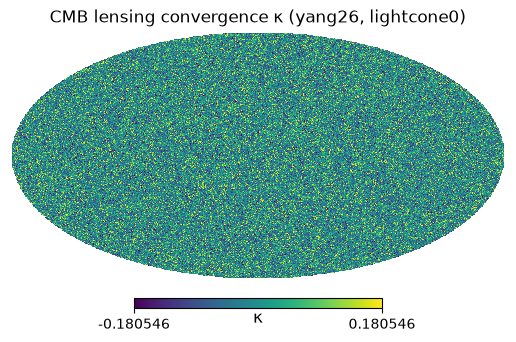

In [3]:
kappa = load_healpix_map(DATA_DIR / "CMB_lensing_rot_same_rot.hdf5")
summarize_map(kappa, "CMB lensing κ")
plot_mollweide(kappa, title="CMB lensing convergence κ (yang26, lightcone0)", unit="κ")

## 2. Thermal Sunyaev–Zel'dovich (tSZ)

The tSZ effect (Yang et al. 2026, §3.3) arises from inverse Compton scattering of CMB
photons off hot electrons. The map stores the dimensionless **Compton-$y$** parameter,
integrated over lightcone shells to $z = 4.5$. Contributions from star-forming gas and
from gas recently heated by AGN feedback are excluded. Lensing has been applied
shell-by-shell (§3.7). Brightest features trace massive clusters and groups.


lensed tSZ (Compton y)
  pixels : 201,326,592
  min    : -2.368968e-05
  max    : 4.794140e-04
  mean   : 1.610907e-06
  std    : 2.069658e-06
  finite : 100.00%


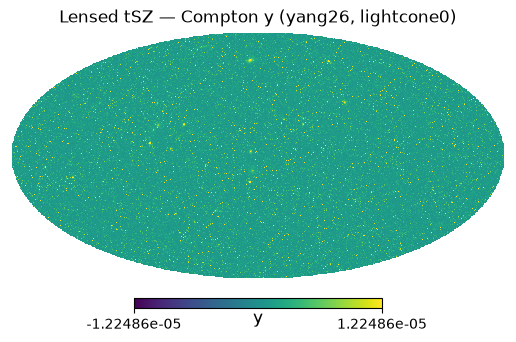

In [4]:
tsz = load_healpix_map(DATA_DIR / "lensed_tSZ_rot_same_rot.hdf5")
summarize_map(tsz, "lensed tSZ (Compton y)")
plot_mollweide(
    tsz,
    title="Lensed tSZ — Compton y (yang26, lightcone0)",
    unit="y",
    pct_limits=(0.5, 99.5),
)

## 3. Kinetic Sunyaev–Zel'dovich (kSZ)

The kSZ effect probes line-of-sight peculiar velocities of free electrons (Yang et al.
2026, §3.3). FLAMINGO stores the dimensionless Doppler parameter $b$, related to the
temperature fluctuation by $T_\mathrm{kSZ}/T_\mathrm{CMB} = -b$ with
$T_\mathrm{CMB} = 2.73\,\mathrm{K}$. The same gas-particle exclusions as for tSZ apply.
Values are small compared to tSZ and show both large-scale dipolar and small-scale structure.


lensed kSZ (T_kSZ/T_CMB = -b)
  pixels : 201,326,592
  min    : -5.338156e-05
  max    : 7.816876e-05
  mean   : -1.300408e-07
  std    : 1.865400e-06
  finite : 100.00%


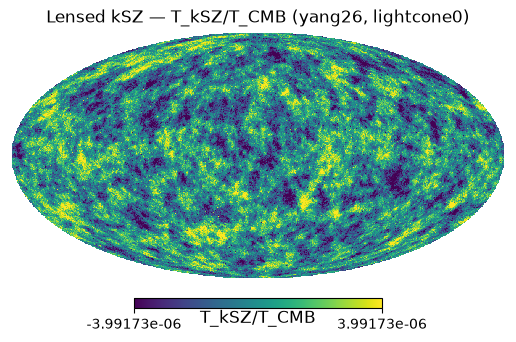

In [5]:
ksz = load_healpix_map(DATA_DIR / "lensed_kSZ_rot_same_rot.hdf5")
summarize_map(ksz, "lensed kSZ (T_kSZ/T_CMB = -b)")
plot_mollweide(
    ksz,
    title="Lensed kSZ — T_kSZ/T_CMB (yang26, lightcone0)",
    unit="T_kSZ/T_CMB",
)

## 4. Dark matter projected mass

The `lensed_DM` map stores the **line-of-sight integrated dark matter mass per HEALPix
pixel**, with gravitational lensing applied shell-by-shell. This traces the collisionless
matter distribution and complements the gas-based tSZ/kSZ and SFR-based CIB maps.
Values are in simulation mass units accumulated per pixel (hence the large dynamic range).


lensed DM projected mass
  pixels : 201,326,592
  min    : 2.871999e+71
  max    : 9.660909e+71
  mean   : 3.640293e+71
  std    : 1.642878e+70
  finite : 100.00%


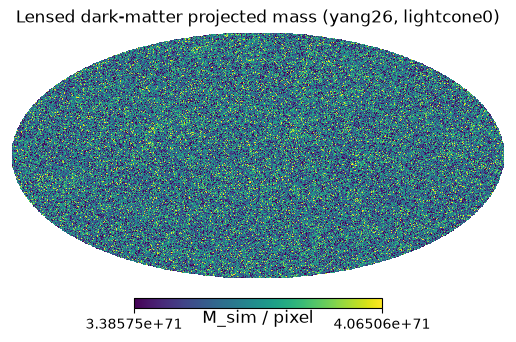

In [6]:
dm = load_healpix_map(DATA_DIR / "lensed_DM_rot_same_rot.hdf5")
summarize_map(dm, "lensed DM projected mass")
plot_mollweide(
    dm,
    title="Lensed dark-matter projected mass (yang26, lightcone0)",
    unit="M_sim / pixel",
    log_scale=True,
    pct_limits=(5, 99),
)

## 5. Cosmic Infrared Background (CIB) — four Planck bands

CIB maps follow the **three-parameter model** of Yang et al. (2026, §3.5.1). Starting from
FLAMINGO SFR lightcone shells, the mapping to observed intensity is:

**1. SFR → bolometric IR luminosity** (Kennicutt 1998; Chabrier IMF):

$$
\frac{L_{\mathrm{bol,IR}}}{1\times 10^{10}\,L_\odot}
=
\frac{\mathrm{SFR}}{1\,M_\odot\,\mathrm{yr}^{-1}}
\qquad (11)
$$

**2. Dust temperature evolution** (power law in redshift):

$$
T_{\mathrm{dust}}(z) = T_0\,(1+z)^{\alpha}
$$

**3. Greybody SED** (Planck Collaboration XV 2016a). For the frequencies and redshifts
used here ($z\le 4.5$, $\nu < 1000\,\mathrm{GHz}$), the high-frequency power-law cut-off is
not needed, so

$$
\Theta(\nu, T_{\mathrm{dust}}, z)
=
\left[\exp\!\left(\frac{h\nu}{k_B T_{\mathrm{dust}}(z)}\right)-1\right]^{-1}
\nu^{\beta_d+3}
\qquad (12)
$$

**4. Specific luminosity** at rest-frame frequency $\nu$:

$$
L_{\nu,\mathrm{IR}}
=
L_{\mathrm{bol,IR}}(\mathrm{SFR})\,
\frac{\Theta(\nu, T_{\mathrm{dust}})}{\displaystyle\int\mathrm{d}\nu'\,\Theta(\nu', T_{\mathrm{dust}})}
\qquad (13)
$$

**5. Observed flux** (and Planck bandpass convolution):

$$
S_{\nu,\mathrm{IR}}
=
\frac{L_{\nu(1+z),\mathrm{IR}}}{4\pi\,\chi^2\,(1+z)}
\qquad (14)
$$

The three free parameters $\boldsymbol{\theta}=[\beta_d,\,T_0,\,\alpha]$ are fit to the auto-power spectra
of Lenz et al. (2019) at 353, 545, and 857 GHz; the same SED is then evaluated (and
convolved with each Planck HFI bandpass) at **217, 353, 545, and 857 GHz**. Shells are
stacked to $z=4.5$ and lensed shell-by-shell (§3.7).


CIB 217 GHz
  pixels : 201,326,592
  min    : -4.230178e+04
  max    : 1.878785e+06
  mean   : 4.292800e+04
  std    : 1.329564e+04
  finite : 100.00%

CIB 353 GHz
  pixels : 201,326,592
  min    : -2.552368e+05
  max    : 9.912533e+06
  mean   : 1.704179e+05
  std    : 5.070649e+04
  finite : 100.00%

CIB 545 GHz
  pixels : 201,326,592
  min    : -1.211847e+06
  max    : 4.153789e+07
  mean   : 4.690086e+05
  std    : 1.364858e+05
  finite : 100.00%

CIB 857 GHz
  pixels : 201,326,592
  min    : -5.121354e+06
  max    : 1.567360e+08
  mean   : 9.480738e+05
  std    : 3.024778e+05
  finite : 100.00%


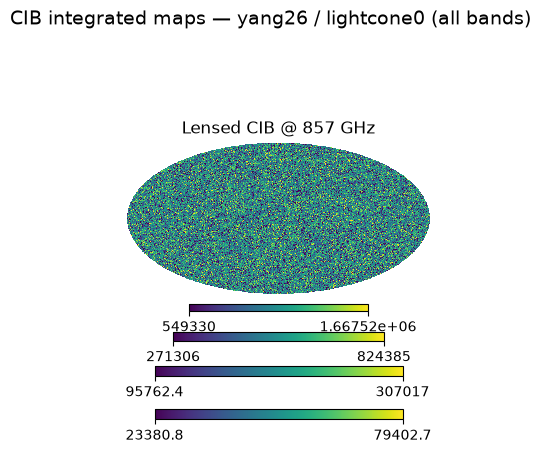

In [7]:
cib_bands = [
    (217, "lensed_CIB_rot_BANDPASS_F217_three_params_same_rot.hdf5"),
    (353, "lensed_CIB_rot_BANDPASS_F353_three_params_same_rot.hdf5"),
    (545, "lensed_CIB_rot_BANDPASS_F545_three_params_same_rot.hdf5"),
    (857, "lensed_CIB_rot_BANDPASS_F857_three_params_same_rot.hdf5"),
]

for i, (freq, fname) in enumerate(cib_bands, start=1):
    m = load_healpix_map(DATA_DIR / fname)
    summarize_map(m, f"CIB {freq} GHz")
    plot_mollweide(
        m,
        title=f"Lensed CIB @ {freq} GHz",
        log_scale=True,
        pct_limits=(5, 99),
        sub=(2, 2, i),
    )

plt.suptitle("CIB integrated maps — yang26 / lightcone0 (all bands)", y=1.02, fontsize=14)
plt.show()

## 6. Overview — all maps at a glance

Quick-look panel of every map type at the current plotting resolution (`NSIDE_PLOT`, controlled by `USE_DOWNGRADE`).

/tmp/ipykernel_35468/1057488279.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


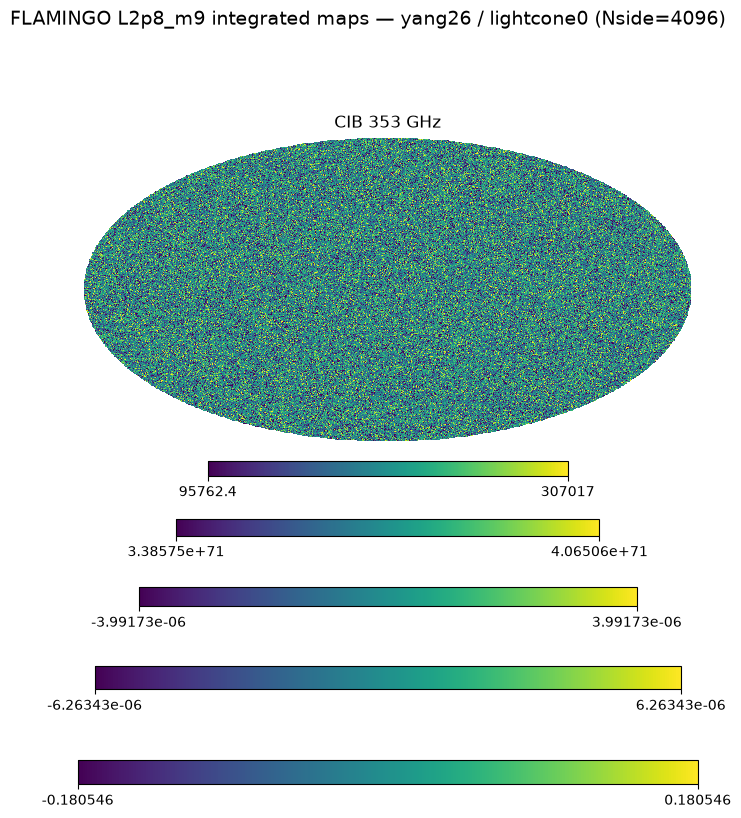

In [8]:
MAP_CATALOG = [
    ("CMB_lensing_rot_same_rot.hdf5", "CMB lensing κ", False),
    ("lensed_tSZ_rot_same_rot.hdf5", "tSZ (y)", False),
    ("lensed_kSZ_rot_same_rot.hdf5", "kSZ (T/T_CMB)", False),
    ("lensed_DM_rot_same_rot.hdf5", "DM projected mass", True),
    ("lensed_CIB_rot_BANDPASS_F353_three_params_same_rot.hdf5", "CIB 353 GHz", True),
]

fig = plt.figure(figsize=(16, 9))

for i, (fname, label, use_log) in enumerate(MAP_CATALOG, start=1):
    m = load_healpix_map(DATA_DIR / fname)
    plot_mollweide(
        m,
        title=label,
        log_scale=use_log,
        pct_limits=(5, 99) if use_log else (2, 98),
        sub=(2, 3, i),
    )

plt.suptitle(
    f"FLAMINGO L2p8_m9 integrated maps — yang26 / lightcone0 (Nside={NSIDE_PLOT})",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.show()

## References

1. **Yang et al. (2026)** — *Self-consistent secondary cosmic microwave background anisotropies and extragalactic foregrounds in the flamingo simulations*, MNRAS 548, 1–26. [doi:10.1093/mnras/stag625](https://doi.org/10.1093/mnras/stag625) · [arXiv:2512.09891](https://doi.org/10.48550/arxiv.2512.09891)
2. **Schaye et al. (2026)** — *The FLAMINGO simulations data release*, arXiv:2604.24324
3. **Schaye et al. (2023)** — *The FLAMINGO project*, MNRAS 526, 4978
4. **Lenz et al. (2019)** — Planck CIB auto-power spectra used to calibrate the three-parameter SED model
5. [FLAMINGO DataWeb documentation](https://dataweb.cosma.dur.ac.uk:8443/flamingo/)

### Next steps

- Cross-correlate tSZ with $\kappa_\mathrm{CMB}$ using these `same_rot` maps (Yang et al. 2026, §4)
- Compare individual redshift shells vs. integrated maps
- Download other lightcones (`lightcone1`–`7`; eight independent realizations for L2p8)
- Use $N_\mathrm{side}=16384$ maps for cluster-scale studies (much larger files)